# NEX-GDDP-CMIP6 Download + Multivariate Bias Correction & Downscaling
## Using HYRAS as reference (1951–1980) · Variables: `pr`, `tas`, `tasmax`, `tasmin`, `rsds`, `hurs`

**Workflow overview:**
1. Download NEX-GDDP-CMIP6 historical & future data via `climdata`
2. Load HYRAS reference observations
3. Align grids (regrid NEX-GDDP → HYRAS grid)
4. Slice to reference period 1951–1980
5. Train multivariate bias correction (MBCn) using `xclim.sdba`
6. Apply correction to full simulation period
7. Post-process & validate outputs
8. Visualise results

## 1 · Import Required Libraries

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import iris

# climdata for data download
from climdata import ClimData

# climdata BCSD pipeline (wraps ISIMIP3BASD)
from climdata.sdba.bcsd import (
    BiasCorrection,
    StatisticalDownscaling,
    BCSD,
    regrid_to_coarse,
)

print("✓ All imports successful")

import dask
import dask.array as da

# ── Dask global config ────────────────────────────────────────────────────────
# "synchronous" is required for two reasons:
#   1. netcdf4 C library is NOT thread-safe — concurrent thread reads cause
#      lock contention; the threads serialise at the C level anyway.
#   2. Safe to fork into multiprocessing workers (no live thread pool to inherit).
# For the .compute() calls below we use a temporary "threads" override with
# large chunk sizes to maximise throughput while staying safe.
dask.config.set({
    "scheduler": "synchronous",   # default: safe for netcdf4 + fork()
    "array.chunk-size": "256MiB", # fewer, larger chunks → fewer tasks
})

print("✓ Dask config: scheduler=synchronous (thread-safe for netcdf4 + multiprocessing)")


✓ All imports successful
✓ Dask config: scheduler=synchronous (thread-safe for netcdf4 + multiprocessing)


## 2 · Configuration & Parameters

In [2]:
# ── Variables ────────────────────────────────────────────────────────────────
VARIABLES = ["pr", "hurs"]#, "tas", "tasmax", "tasmin", "rsds", "hurs"]

# ── Periods ──────────────────────────────────────────────────────────────────
REF_START   = "1951-01-01"   # HYRAS reference period start
REF_END     = "1980-12-31"   # HYRAS reference period end

HIST_START  = "1951-01-01"   # NEX-GDDP historical download start
HIST_END    = "2014-12-31"   # NEX-GDDP historical download end

FUT_START   = "2015-01-01"   # NEX-GDDP future download start
FUT_END     = "2100-12-31"   # NEX-GDDP future download end

# ── NEX-GDDP model & scenario ─────────────────────────────────────────────────
SOURCE_ID    = "GFDL-ESM4"   # CMIP6 model name
MEMBER_ID    = "r1i1p1f1"
SCENARIO     = "ssp370"          # future scenario

# ── Region (Germany / Central Europe) ─────────────────────────────────────────
REGION = "germany"

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = "/data01/FDS/muduchuru/Atmos/"
OUTPUT_DIR = os.path.join(DATA_DIR, "NEXGDDP_HYRAS_ISIMIP3BASD")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration:")
print(f"  Variables  : {VARIABLES}")
print(f"  Ref period : {REF_START} → {REF_END}")
print(f"  Model      : {SOURCE_ID} / {MEMBER_ID}")
print(f"  Scenario   : {SCENARIO}")
print(f"  Output dir : {OUTPUT_DIR}")

Configuration:
  Variables  : ['pr', 'hurs']
  Ref period : 1951-01-01 → 1980-12-31
  Model      : GFDL-ESM4 / r1i1p1f1
  Scenario   : ssp370
  Output dir : /data01/FDS/muduchuru/Atmos/NEXGDDP_HYRAS_ISIMIP3BASD


## 3 · Download NEX-GDDP-CMIP6 Data

Download both **historical** (1951–2014) and **future** scenario data via `climdata`'s `ClimData` extractor.  
NEX-GDDP provides statistically downscaled CMIP6 projections at **0.25°** (~25 km) globally.

In [ ]:

import copy
from concurrent.futures import ThreadPoolExecutor, as_completed
import time

def load(extractor, dataset, start, end, experiment=None, cache_path=None, force=False):
    if cache_path and os.path.exists(cache_path) and not force:
        print(f"  📂 Loading from cache: {cache_path}")
        return xr.open_dataset(cache_path)

    # work on a private copy so concurrent threads don't share mutable cfg
    ext = copy.deepcopy(extractor)
    ext.cfg.dataset = dataset
    ext.cfg.time_range.start_date = start
    ext.cfg.time_range.end_date = end
    if dataset == "hyras":
        ext.cfg.data_dir = ext.cfg.data_dir + 'DWD'
    if experiment is not None:
        ext.cfg.experiment_id = experiment
    ds = ext.extract()

    if cache_path:
        os.makedirs(os.path.dirname(cache_path), exist_ok=True)
        ds.to_netcdf(cache_path)
        print(f"  💾 Saved to cache: {cache_path}")

    return ds

FORCE_RELOAD = False   # set True to re-download and overwrite cached files

print("Loading all 3 datasets in parallel ...")
t0 = time.time()

overrides = [
    f"region={REGION}",
    f"variables={VARIABLES}",
    f"data_dir={DATA_DIR}",
    f"source_id={SOURCE_ID}",
]
extractor = ClimData(overrides=overrides)

_cache = os.path.join(OUTPUT_DIR, "cache")
tasks = {
    "sim_hist": dict(extractor=extractor, dataset='nexgddp', start=HIST_START, end=HIST_END,
                     experiment='historical',
                     cache_path=os.path.join(_cache, f"sim_hist_{SOURCE_ID}_{HIST_START[:4]}-{HIST_END[:4]}.nc"),
                     force=FORCE_RELOAD),
    "sim_fut":  dict(extractor=extractor, dataset='nexgddp', start=FUT_START, end=FUT_END,
                     experiment=SCENARIO,
                     cache_path=os.path.join(_cache, f"sim_fut_{SOURCE_ID}_{SCENARIO}_{FUT_START[:4]}-{FUT_END[:4]}.nc"),
                     force=FORCE_RELOAD),
    "obs_raw":  dict(extractor=extractor, dataset='hyras', start=REF_START, end=REF_END,
                     cache_path=os.path.join(_cache, f"obs_raw_HYRAS_{REF_START[:4]}-{REF_END[:4]}.nc"),
                     force=FORCE_RELOAD),
}

results = {}
with ThreadPoolExecutor(max_workers=1) as pool:
    futures = {pool.submit(load, **kwargs): name for name, kwargs in tasks.items()}
    for fut in as_completed(futures):
        name = futures[fut]
        try:
            results[name] = fut.result()
        except Exception as exc:
            print(f"  ⚠️  {name} failed: {exc}")
            raise

sim_hist = results["sim_hist"]
sim_fut  = results["sim_fut"]
obs_raw  = results["obs_raw"]

print(f"\n✅ All datasets ready in {time.time() - t0:.1f}s")
print(sim_hist)
print(sim_fut)
print(obs_raw)


Loading all 3 datasets in parallel ...
  📂 Loading from cache: /data01/FDS/muduchuru/Atmos/NEXGDDP_HYRAS_ISIMIP3BASD/cache/sim_hist_GFDL-ESM4_1951-2014.nc
  📂 Loading from cache: /data01/FDS/muduchuru/Atmos/NEXGDDP_HYRAS_ISIMIP3BASD/cache/sim_fut_GFDL-ESM4_ssp370_2015-2100.nc
⬇️  Checking: https://opendata.dwd.de/climate_environment/CDC/grids_germany/daily/hyras_de/precipitation/pr_hyras_1_1951_v6-1_de.nc
✔️  Exists locally: /data01/FDS/muduchuru/Atmos/DWD/HYRAS/PR/pr_hyras_1_1951_v6-1_de.nc
⬇️  Checking: https://opendata.dwd.de/climate_environment/CDC/grids_germany/daily/hyras_de/precipitation/pr_hyras_1_1952_v6-1_de.nc
✔️  Exists locally: /data01/FDS/muduchuru/Atmos/DWD/HYRAS/PR/pr_hyras_1_1952_v6-1_de.nc
⬇️  Checking: https://opendata.dwd.de/climate_environment/CDC/grids_germany/daily/hyras_de/precipitation/pr_hyras_1_1953_v6-1_de.nc
✔️  Exists locally: /data01/FDS/muduchuru/Atmos/DWD/HYRAS/PR/pr_hyras_1_1953_v6-1_de.nc
⬇️  Checking: https://opendata.dwd.de/climate_environment/CDC/g

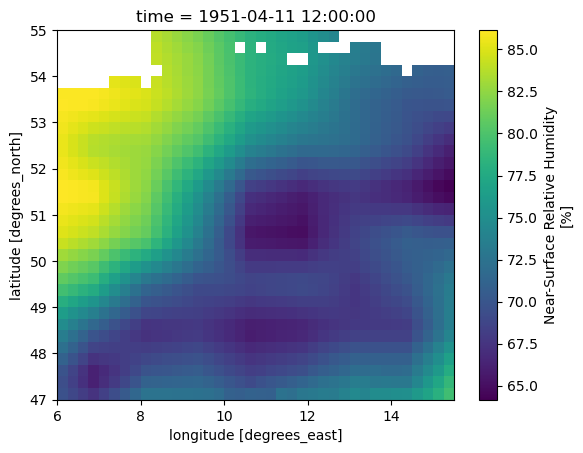

## 4 · Load & Preprocess HYRAS Reference Dataset

HYRAS provides gridded observations for Germany at **5 km** resolution.  
We load all six variables and standardise units to match NEX-GDDP conventions.

In [ ]:

# ── Datasets are already in RAM (load() uses ThreadPoolExecutor + .load()) ───
# NEXGDDP.load() now opens each annual file in a thread, clips to region via
# _extract_preprocess, and calls ds.load() inside the thread — returning plain
# numpy arrays.  No dask arrays, no .compute(), no unify_chunks() needed.

import os, psutil

def _get_nbytes(ds):
    total = 0
    for v in ds.data_vars:
        arr = ds[v]
        total += arr.size * arr.dtype.itemsize
    return total

available_gb = psutil.virtual_memory().available / 1e9
total_bytes  = sum(_get_nbytes(ds) for ds in [sim_hist, sim_fut, obs_raw])
needed_gb    = total_bytes / 1e9

print("Datasets already in RAM (ThreadPoolExecutor load, no dask):")
for name, ds in [("sim_hist", sim_hist), ("sim_fut", sim_fut), ("obs_raw", obs_raw)]:
    nb = _get_nbytes(ds)
    print(f"  {name:<10} {nb/1e6:>6.1f} MB   dims={dict(ds.dims)}")
print(f"\n  Available RAM : {available_gb:.1f} GB  |  Used : {needed_gb:.3f} GB")

# Derive reference-period slices and coarsened obs — pure numpy ops
obs_coarse = regrid_to_coarse(obs_raw, sim_hist, method='bilinear')
sim_ref    = sim_hist.sel(time=slice(REF_START, REF_END))
obs_ref    = obs_coarse.sel(time=slice(REF_START, REF_END))

print("\n✓ Ready for bias correction")
for name, ds in [("sim_ref", sim_ref), ("obs_ref", obs_ref)]:
    print(f"  {name:<10} { {v: ds[v].shape for v in ds.data_vars} }")


Datasets already in RAM (ThreadPoolExecutor load, no dask):
  sim_hist    227.2 MB   dims={'time': 23360, 'lat': 32, 'lon': 38}
  sim_fut     305.4 MB   dims={'time': 31390, 'lat': 32, 'lon': 38}
  obs_raw    76304.5 MB   dims={'time': 10958, 'y': 890, 'x': 652}

  Available RAM : 79.5 GB  |  Used : 76.837 GB
🔄 Regridding from fine to coarse resolution using xesmf...
   Fine grid: FrozenMappingWarningOnValuesAccess({'time': 10958, 'y': 890, 'x': 652})
   Target coarse grid: FrozenMappingWarningOnValuesAccess({'time': 23360, 'lat': 32, 'lon': 38})
   Creating bilinear regridder...
   Regridding variable: pr
   Regridding variable: hurs


In [ ]:

# ── Multivariate Bias Correction (MBCn) ──────────────────────────────────────
# All variables are corrected JOINTLY in one call.
# n_iterations > 0 activates the MBCn copula rotation that preserves the
# inter-variable dependence structure (e.g. pr–hurs correlation).
#
# BiasCorrection.correct(obs_hist, sim_hist, sim_fut) → merged xr.Dataset
#   obs_hist : coarse HYRAS, reference period only (1951–1980)
#   sim_hist : NEX-GDDP historical, reference period only
#   sim_fut  : full NEX-GDDP future (2015–2100) – entire period is corrected

bc = BiasCorrection(
    variable=VARIABLES,      # pass the full variable list → multivariate MBCn
    n_iterations=20,         # MBCn rotations; 0 = univariate quantile mapping only
    n_processes=32,
    randomization_seed=42,
)

bc_result = bc.correct(
    obs_hist=obs_ref,        # coarse HYRAS, 1951–1980
    sim_hist=sim_ref,        # NEX-GDDP historical, 1951–1980
    sim_fut=sim_fut,         # NEX-GDDP future,  2015–2100
    output_path=os.path.join(OUTPUT_DIR, f"{SOURCE_ID}_{MEMBER_ID}_{SCENARIO}_BC.nc"),
)

print("\n✅ Multivariate bias correction complete")
print(bc_result)


In [ ]:
bc_result.isel()

In [ ]:

# ── KDE: obs_ref vs sim_fut (raw) vs bc_result (corrected) ───────────────────
from scipy.stats import gaussian_kde

n_vars = len(VARIABLES)
fig, axes = plt.subplots(1, n_vars, figsize=(6 * n_vars, 5), squeeze=False)

# Use the overlapping future period for a fair comparison
time_slice = slice(FUT_START, "2050-12-31")   # first 35 years of future

for ax, var in zip(axes[0], VARIABLES):
    # --- collect data arrays (flatten to 1D, drop NaNs) ---
    def _flat(ds, v, tsl=None):
        arr = ds[v]
        if tsl:
            arr = arr.sel(time=tsl)
        vals = np.asarray(arr).ravel()
        return vals[~np.isnan(vals)]

    # obs: reference period coarse (same grid as sim)
    obs_vals  = _flat(obs_ref,    var)
    # sim_fut: raw future (full period, subsample for speed)
    raw_vals  = _flat(sim_fut,    var, time_slice)
    # bc_result: bias-corrected future
    cor_vals  = _flat(bc_result,  var, time_slice)

    for vals, label, color, ls in [
        (obs_vals, f"obs (HYRAS {REF_START[:4]}–{REF_END[:4]})", "#2ca02c", "-"),
        (raw_vals, f"sim_fut raw ({FUT_START[:4]}–2050)",        "#1f77b4", "--"),
        (cor_vals, f"sim_fut corrected ({FUT_START[:4]}–2050)",  "#d62728", "-"),
    ]:
        if len(vals) < 10:
            continue
        kde = gaussian_kde(vals, bw_method="scott")
        x = np.linspace(vals.min(), vals.max(), 500)
        ax.plot(x, kde(x), lw=2, label=label, color=color, linestyle=ls)

    ax.set_title(f"KDE — {var}", fontsize=13)
    ax.set_xlabel(var)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f"Bias Correction effect · {SOURCE_ID} {MEMBER_ID} {SCENARIO}",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()


## 6 · Statistical Downscaling (coarse 0.25° → fine 5 km HYRAS grid)

Apply **ISIMIP3BASD modified MBCn** spatial downscaling for each variable.

- `obs_fine`   = raw HYRAS at 5 km (reference period), used to learn spatial patterns  
- `sim_coarse` = bias-corrected NEX-GDDP from Step 5 (coarse grid, full future period)


In [ ]:

# ── Statistical Downscaling: per variable ────────────────────────────────────
# Downscaling is applied per variable (spatial MBCn is univariate in space).
# obs_fine   = raw HYRAS at 5 km (1951–1980), teaches fine-scale spatial patterns
# sim_coarse = variable slice of the multivariate bias-corrected Dataset above

sd_results = {}   # { var: xr.Dataset (fine-resolution BCSD output) }

for var in VARIABLES:
    print(f"\n{'='*60}")
    print(f"Downscaling: {var}")
    print(f"{'='*60}")

    sd = StatisticalDownscaling(
        variable=var,
        n_iterations=20,
        n_processes=4,
        randomization_seed=42,
    )

    sd_out = sd.downscale(
        obs_fine=obs_raw,                   # fine HYRAS at 5 km (1951–1980)
        sim_coarse=bc_result[[var]],        # bias-corrected coarse slice for this var
        output_path=os.path.join(OUTPUT_DIR, f"{SOURCE_ID}_{MEMBER_ID}_{SCENARIO}_{var}_BCSD.nc"),
    )

    sd_results[var] = sd_out
    print(f"✓ {var} downscaled | shape: {sd_out[var].shape}")

print("\n✅ Statistical downscaling complete for all variables")
